# Assignment 5: Reducing High-Dimensional Data with PCA

**Student Name:** [Baigali Nyamdulam]

**Date:** [03/01/2026]

---

## Assignment Overview

You've joined the data science team at FitTrack Analytics, a company that develops fall detection systems for elderly care facilities. Their wearable devices capture 561 sensor features from accelerometer and gyroscope readings. Your task: use Principal Component Analysis (PCA) to compress this high-dimensional data into something you can visualize, understand, and build reliable models from.

---

## Step 1: Import Libraries and Load Data

In [1]:
#pip install pandas matplotlib seaborn scikit-learn

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from mpl_toolkits.mplot3d import Axes3D

# Set random seed for reproducibility
np.random.seed(42)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [5]:
# Load the Human Activity Recognition dataset
# TODO: Load train.csv and test.csv from the data folder
train_df = pd.read_csv('data/train.csv')  # Replace with pd.read_csv()
test_df = pd.read_csv('data/test.csv')   # Replace with pd.read_csv()

# TODO: Separate features from labels
# Create X_train, y_train, X_test, y_test
# The 'Activity' column contains the labels
X_train = train_df.drop('Activity', axis=1)
y_train = train_df['Activity']
X_test = test_df.drop('Activity', axis=1)
y_test = test_df['Activity']

print(y_train.unique())

print("\n" + "="*80)
print("CHECKPOINT: Verify dataset loaded correctly")
print(f"Training set shape: {X_train.shape if X_train is not None else 'Not loaded'}")
print(f"Test set shape: {X_test.shape if X_test is not None else 'Not loaded'}")
print(f"Number of features: {X_train.shape[1] if X_train is not None else 'N/A'}")
print(f"Unique activities: {y_train.nunique() if y_train is not None else 'N/A'}")
print("="*80)

['STANDING' 'SITTING' 'LAYING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']

CHECKPOINT: Verify dataset loaded correctly
Training set shape: (7352, 562)
Test set shape: (2947, 562)
Number of features: 562
Unique activities: 6


---
## Step 2: Experience the Problem - Try to Understand 561 Dimensions

### Attempt Visualization with 2 Features

['WALKING' 'STANDING' 'LAYING' 'WALKING_DOWNSTAIRS' 'WALKING_UPSTAIRS'
 'SITTING']


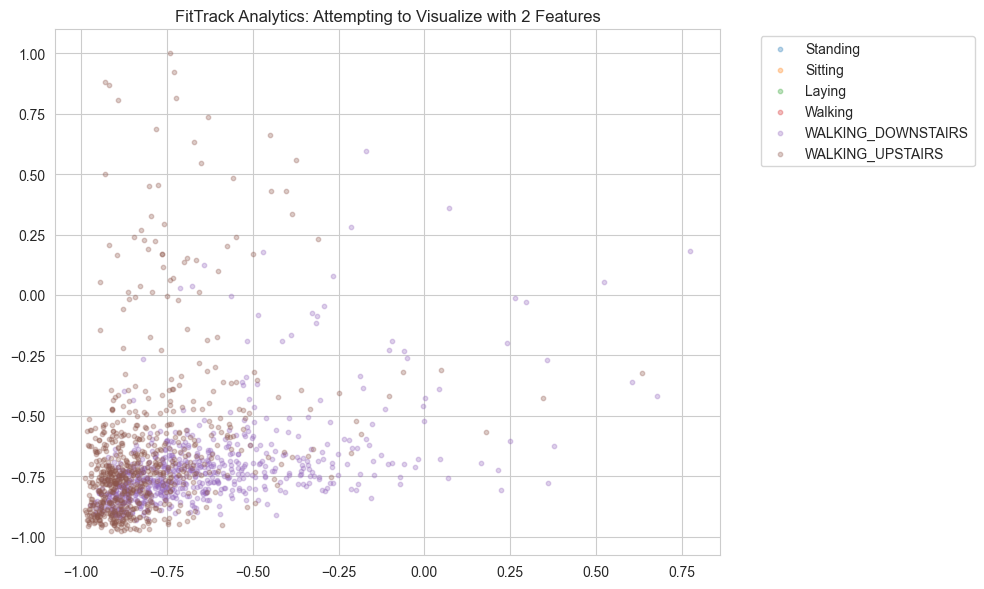

In [17]:
# TODO: Create a scatter plot using any 2 of the 561 features
# Color points by activity type
# Can you see clear patterns separating the six activities?

# Try plotting pixel 400 vs pixel 500 (arbitrary choices)
# Sample 5000 points to make the plot readable

label_names = {0: 'Standing', 1: 'Sitting', 2: 'Laying', 3: 'Walking', 4: 'WALKING_DOWNSTAIRS', 5: 'WALKING_UPSTAIRS'}

sample_size = 5000
sample_indices = np.random.choice(len(X_train), sample_size, replace=False)
X_sample = X_train.iloc[sample_indices]
y_sample = y_train.iloc[sample_indices]

print(y_sample.unique())
plt.figure(figsize=(10, 6))
for label in label_names.values():
    mask = y_sample == label
    plt.scatter(
        X_sample.loc[mask].iloc[:, 400],
        X_sample.loc[mask].iloc[:, 500],
        alpha=0.3,
        s=10,
        label=label
    )

plt.title('FitTrack Analytics: Attempting to Visualize with 2 Features')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### Check Feature Correlations

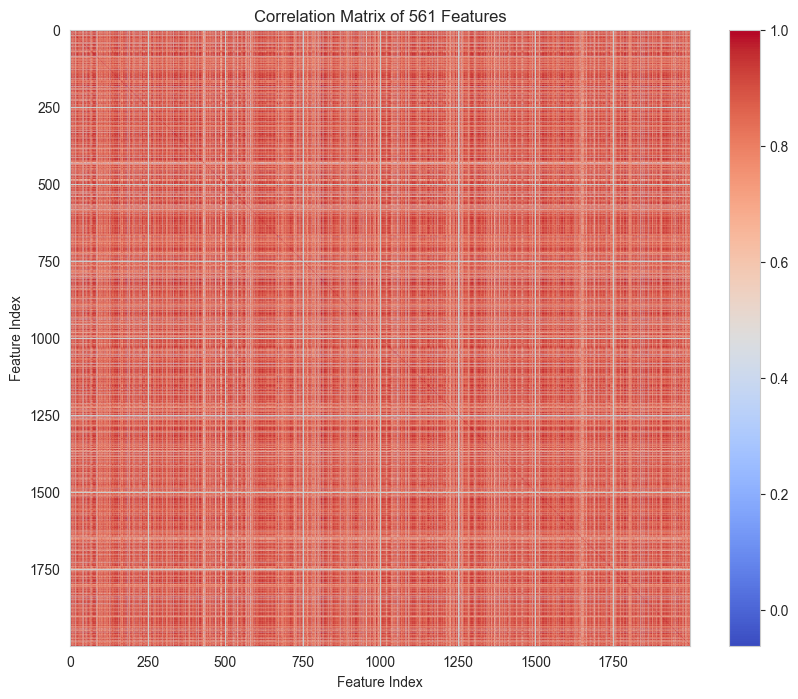

Correlation matrix shape: (2000, 2000)


In [19]:
# TODO: Create a correlation heatmap of all 561 features
# Is it readable? Can you identify redundant features?

# Sample 5000 images to make computation manageable
sample_indices = np.random.choice(len(X_train), 2000, replace=False)
X_sample = X_train.iloc[sample_indices]

# Calculate correlation matrix
corr_matrix = X_sample.T.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.title('Correlation Matrix of 561 Features')
plt.xlabel('Feature Index')
plt.ylabel('Feature Index')
plt.show()

print(f"Correlation matrix shape: {corr_matrix.shape}")

### Train Baseline Model

In [20]:
start_time = time.time()

# TODO: Train a RandomForestClassifier with n_estimators=100, random_state=42
# Your code here
baseline_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
baseline_model.fit(X_train, y_train)
# Calculates baseline training time
baseline_time = time.time() - start_time

# TODO: Calculate accuracy on test set
y_pred = baseline_model.predict(X_test)
baseline_accuracy = accuracy_score(y_test, y_pred)

print("\n" + "="*80)
print("BASELINE MODEL RESULTS")
print(f"Number of features: {X_train.shape[1]}")
print(f"Accuracy: {baseline_accuracy if baseline_accuracy else 'Not calculated'}")
print(f"Training time: {baseline_time:.2f} seconds")
print("="*80)


BASELINE MODEL RESULTS
Number of features: 562
Accuracy: 0.9260264675941635
Training time: 7.43 seconds


### Reflection on High-Dimensional Data
In the Markdown cell below this step, write 2-3 sentences responding to the following question: 
- What problems did you encounter trying to understand 561 dimensions?

[The training took 7.43 seconds. Also, the previous visualitzaions including the heat map were nowhere near interpretable. In conclusion, trying to understand all 561 dimensions on their own is close to impossible (and would take too much time)]

---
## Step 3: Apply PCA to Visualize in 2D and 3D

### Standardize Features

In [21]:
# TODO: Use StandardScaler to normalize all 562 features
# Fit on training data, transform both training and test data

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Replace with scaled training data using scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)   # Replace with scaled test data using scaler.transform(X_test)

# Convert back to DataFrame for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("\n" + "="*80)
print("CHECKPOINT: Features Standardized")
print(f"Scaled training shape: {X_train_scaled.shape if X_train_scaled is not None else 'Not scaled'}")
print("="*80)


CHECKPOINT: Features Standardized
Scaled training shape: (7352, 562)


### Apply PCA for 2 Components

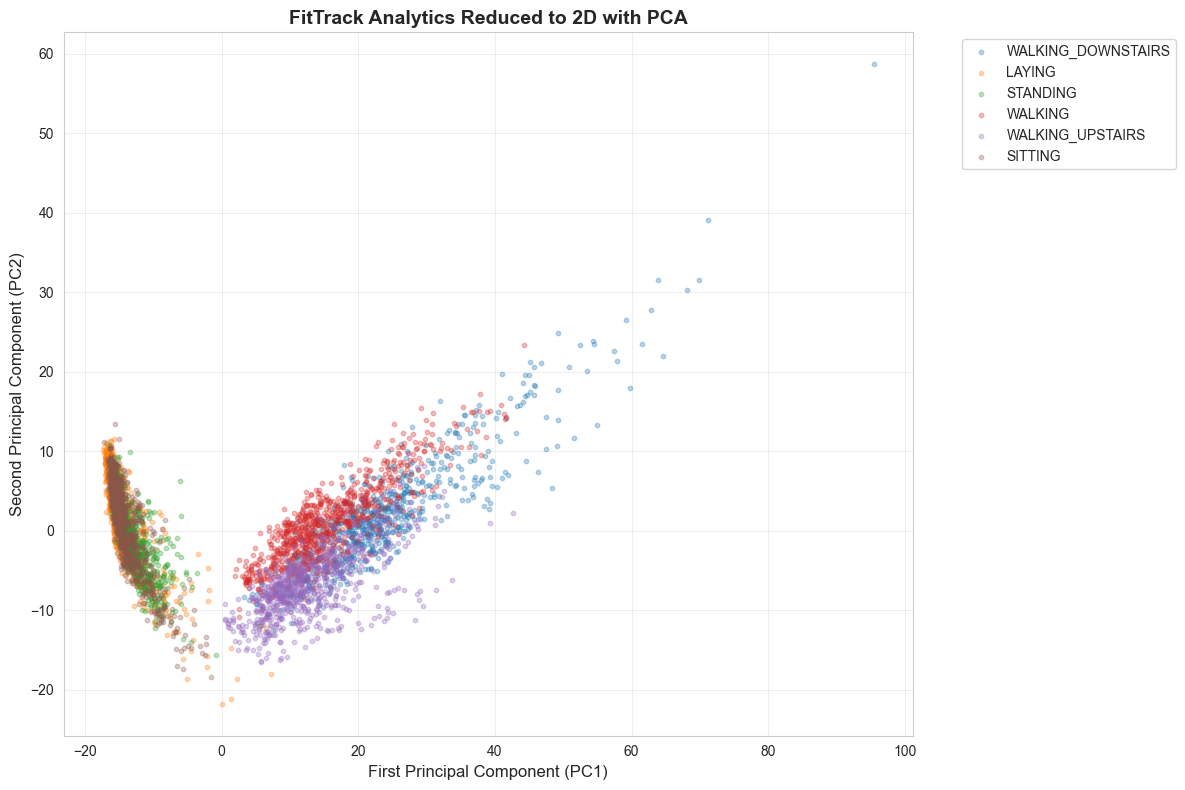


PCA TRANSFORMATION TO 2D
Original dimensions: 562
Reduced dimensions: 2
Variance explained by PC1: 50.69%
Variance explained by PC2: 6.57%
Total variance explained: 57.26%


In [33]:
# TODO: Use PCA(n_components=2)
# Fit on standardized training data, transform both sets

pca_2d = PCA(n_components=2)
X_train_pca_2d = pca_2d.fit_transform(X_train_scaled)  # Replace with PCA-transformed training data using pca_2d.fit_transform(X_train_scaled)
X_test_pca_2d = pca_2d.transform(X_test_scaled)   # Replace with PCA-transformed test data using pca_2d.transform(X_test_scaled)

# TODO: Create scatter plot using the 2 principal components
# Color by activity type, add title, axis labels (PC1, PC2), and legend

label_names = {0: 'Standing', 1: 'Sitting', 2: 'Laying', 3: 'Walking', 4: 'WALKING_DOWNSTAIRS', 5: 'WALKING_UPSTAIRS'}

plt.figure(figsize=(12, 8))

# Sample 5000 points for readable visualization
sample_size = 5000
sample_indices = np.random.choice(len(X_train_pca_2d), sample_size, replace=False)
X_sample = X_train_pca_2d[sample_indices]
y_sample = y_train.iloc[sample_indices]

for label in y_sample.unique():
    mask = y_sample == label
    plt.scatter(X_sample[mask, 0], X_sample[mask, 1], alpha=0.3, s=10, label=label)

plt.xlabel('First Principal Component (PC1)', fontsize=12)
plt.ylabel('Second Principal Component (PC2)', fontsize=12)
plt.title('FitTrack Analytics Reduced to 2D with PCA', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("\n" + "="*80)
print("PCA TRANSFORMATION TO 2D")
print("="*80)
print(f"Original dimensions: {X_train_scaled.shape[1]}")
print(f"Reduced dimensions: {X_train_pca_2d.shape[1]}")
print(f"Variance explained by PC1: {pca_2d.explained_variance_ratio_[0]:.2%}")
print(f"Variance explained by PC2: {pca_2d.explained_variance_ratio_[1]:.2%}")
print(f"Total variance explained: {pca_2d.explained_variance_ratio_.sum():.2%}")
print("="*80)

### Apply PCA for 3 Components


PCA TRANSFORMATION TO 3D
Variance explained by PC1: 50.69%
Variance explained by PC2: 6.57%
Variance explained by PC3: 2.80%
Total variance explained: 60.06%


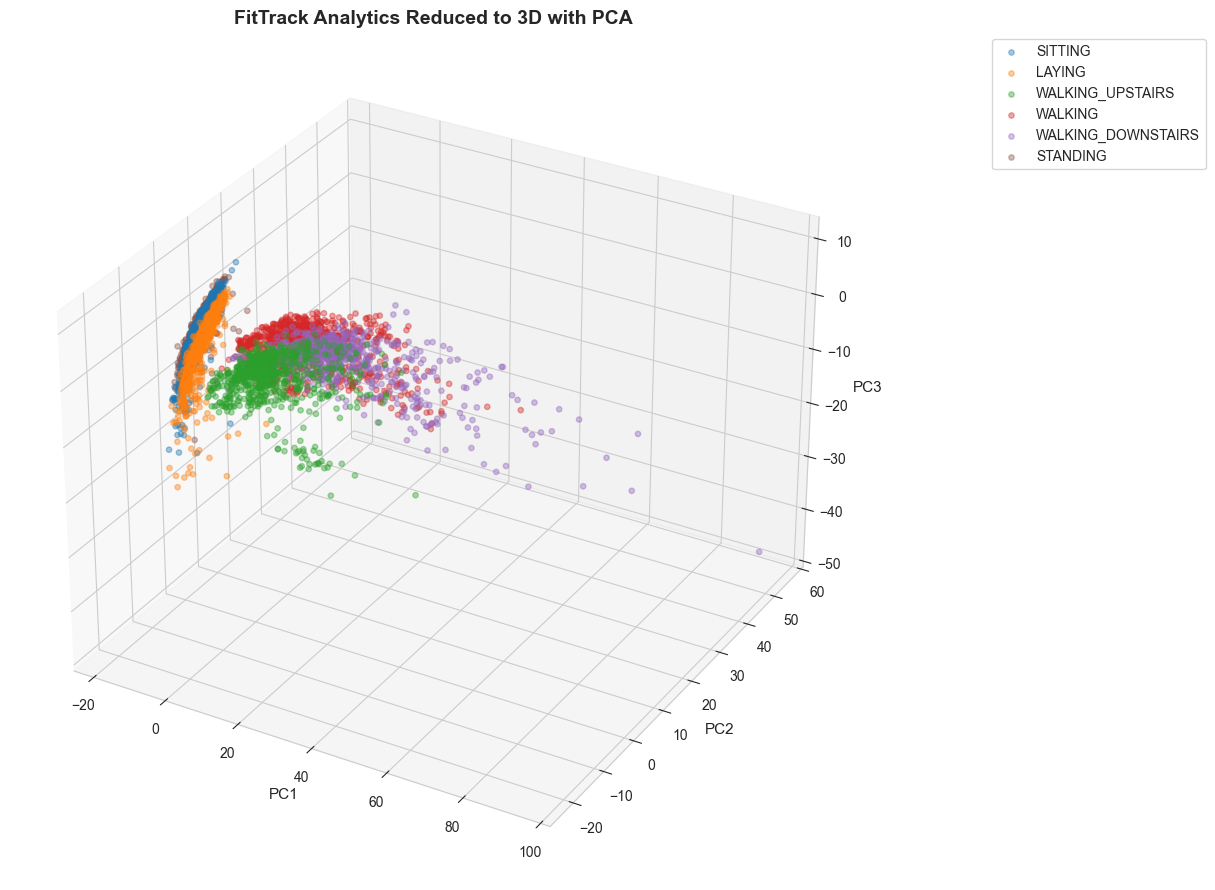

In [32]:
# TODO: Use PCA(n_components=3)
# Fit on standardized training data, transform both sets

pca_3d = PCA(n_components=3)
X_train_pca_3d = pca_3d.fit_transform(X_train_scaled)  # Replace with PCA-transformed training data using pca_3d.fit_transform(X_train_scaled)
X_test_pca_3d = pca_3d.transform(X_test_scaled)   # Replace with PCA-transformed test data using pca_3d.transform(X_test_scaled)
print("\n" + "="*80)
print("PCA TRANSFORMATION TO 3D")
print("="*80)
print(f"Variance explained by PC1: {pca_3d.explained_variance_ratio_[0]:.2%}")
print(f"Variance explained by PC2: {pca_3d.explained_variance_ratio_[1]:.2%}")
print(f"Variance explained by PC3: {pca_3d.explained_variance_ratio_[2]:.2%}")
print(f"Total variance explained: {pca_3d.explained_variance_ratio_.sum():.2%}")
print("="*80)
# TODO: Create 3D scatter plot using the 3 principal components
# Use mpl_toolkits.mplot3d.Axes3D
# Color by activity type
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Sample points for readable visualization
sample_size = 5000
sample_indices = np.random.choice(len(X_train_pca_3d), sample_size, replace=False)
X_sample = X_train_pca_3d[sample_indices]
y_sample = y_train.iloc[sample_indices]
label_names = {0: 'Standing', 1: 'Sitting', 2: 'Laying', 3: 'Walking', 4: 'WALKING_DOWNSTAIRS', 5: 'WALKING_UPSTAIRS'}

for label in y_sample.unique():
    mask = y_sample == label
    ax.scatter(X_sample[mask, 0], X_sample[mask, 1], X_sample[mask, 2], alpha=0.4, s=15, label=label)

ax.set_xlabel('PC1', fontsize=11)
ax.set_ylabel('PC2', fontsize=11)
ax.set_zlabel('PC3', fontsize=11)
ax.set_title('FitTrack Analytics Reduced to 3D with PCA', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.15, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Reflection on PCA Visualization
In the Markdown cell below this step, write 2-3 sentences responding to the following questions: 
- What activity patterns can you now see? 
- Which activities cluster together?

[Right off the bat, I can see that laying down, standing, and sitting are grouped together which I think is appropriate as these actions are stationary. On the other hand, walking, walking downstairs, and walking upstairs are in the same group for they are non-stationary movements unlike the previous group. As for patterns, the stationary group has clear downward trend in PC1 VS PC2 while the non-stationary group has clear upward trend in PC1 VS PC2.]

---
## Step 4: Determine Optimal Number of Components Using Explained Variance

### Create Scree Plot

EXPLAINED VARIANCE BY COMPONENT
Total components available: 100

PC1 explains: 50.69% of variance
PC2 explains: 6.57% of variance
PC3 explains: 2.80% of variance
PC4 explains: 2.50% of variance
PC5 explains: 1.88% of variance

CUMULATIVE EXPLAINED VARIANCE
First 10 components: 70.70%
First 20 components: 77.26%
First 30 components: 81.68%
First 50 components: 87.42%
First 100 components: 94.82%


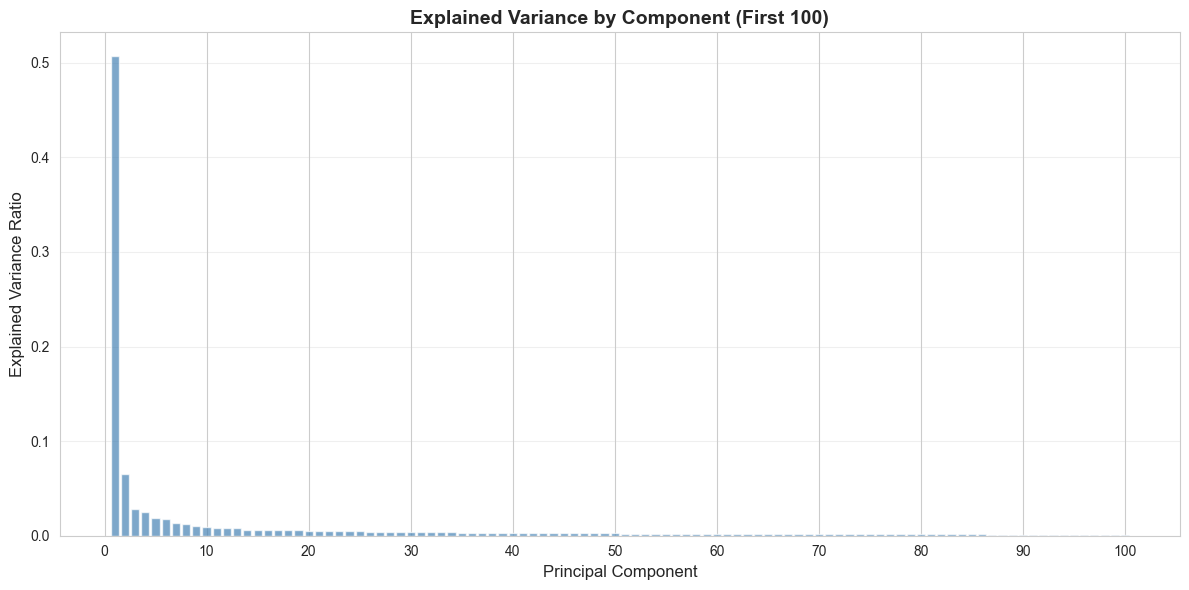

In [40]:
# Fit PCA(n_components=100) to standardized training data
pca_full = PCA(n_components=100)
pca_full.fit(X_train_scaled)

# Get explained variance for each component
explained_variance = pca_full.explained_variance_ratio_
n_components_total = len(explained_variance)

print("="*80)
print("EXPLAINED VARIANCE BY COMPONENT")
print("="*80)
print(f"Total components available: {n_components_total}")
print(f"\nPC1 explains: {explained_variance[0]:.2%} of variance")
print(f"PC2 explains: {explained_variance[1]:.2%} of variance")
print(f"PC3 explains: {explained_variance[2]:.2%} of variance")
print(f"PC4 explains: {explained_variance[3]:.2%} of variance")
print(f"PC5 explains: {explained_variance[4]:.2%} of variance")


# Your code here

# TODO: Plot explained variance ratio for each component
# Use pca_full.explained_variance_ratio_ to get the ratios
# Use np.cumsum() to compute cumulative variance 
cumulative_variance = np.cumsum(explained_variance)
print("\n" + "="*80)
print("CUMULATIVE EXPLAINED VARIANCE")
print("="*80)
print(f"First 10 components: {cumulative_variance[9]:.2%}")
print(f"First 20 components: {cumulative_variance[19]:.2%}")
print(f"First 30 components: {cumulative_variance[29]:.2%}")
print(f"First 50 components: {cumulative_variance[49]:.2%}")
print(f"First 100 components: {cumulative_variance[99]:.2%}")
print("="*80)


# TODO: Plot cumulative explained variance

plt.figure(figsize=(12, 6))
plt.bar(range(1, 101), explained_variance[:100], alpha=0.7, color='steelblue')
plt.xlabel('Principal Component', fontsize=12)
plt.ylabel('Explained Variance Ratio', fontsize=12)
plt.title('Explained Variance by Component (First 100)', fontsize=14, fontweight='bold')
plt.xticks(range(0, 101, 10))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Analyze the Elbow

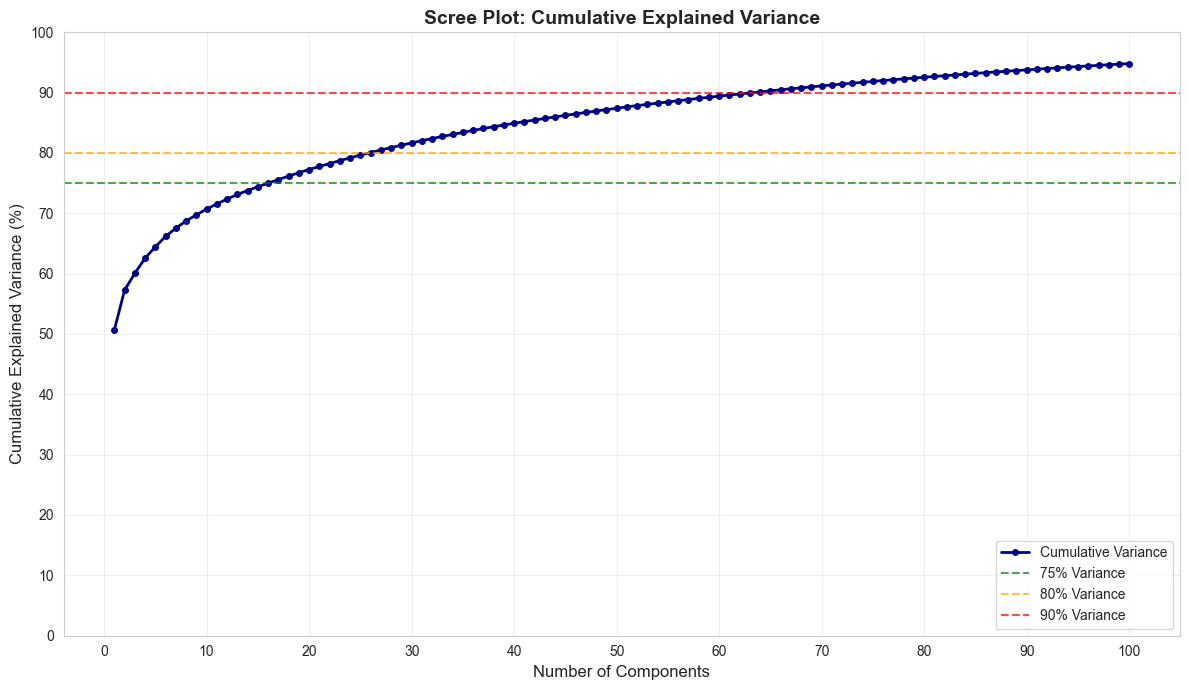


EXPLAINED VARIANCE ANALYSIS
75% variance:  16 components (actual: 75.01%)
80% variance:  26 components (actual: 80.07%)
90% variance:  64 components (actual: 90.13%)
(np.int64(16), np.float64(0.750081128863679))


In [45]:
# TODO: Identify how many components capture 75%, 80%, and variance
# You can use pca_full.explained_variance_ratio_ and np.cumsum()

def find_components_for_variance(cumulative_variance, threshold):
    """Find minimum components needed to reach variance threshold"""
    components_needed = np.argmax(cumulative_variance >= threshold) + 1
    actual_variance = cumulative_variance[components_needed - 1]
    return components_needed, actual_variance
components_75 = find_components_for_variance(cumulative_variance, 0.75)  # Replace with number of components for 75%
components_80 = find_components_for_variance(cumulative_variance, 0.80)   # Replace with number of components for 80%
components_90 = find_components_for_variance(cumulative_variance, 0.90)   # Replace with number of components for 90%



# Create scree plot
plt.figure(figsize=(12, 7))

# Plot cumulative variance
plt.plot(range(1, 101), cumulative_variance[:100] * 100, 
         marker='o', linewidth=2, markersize=4, color='darkblue', label='Cumulative Variance')

# Add grid lines for common thresholds
plt.axhline(y=75, color='green', linestyle='--', alpha=0.7, linewidth=1.5, label='75% Variance')
plt.axhline(y=80, color='orange', linestyle='--', alpha=0.7, linewidth=1.5, label='80% Variance')
plt.axhline(y=90, color='red', linestyle='--', alpha=0.7, linewidth=1.5, label='90% Variance')

plt.xlabel('Number of Components', fontsize=12)
plt.ylabel('Cumulative Explained Variance (%)', fontsize=12)
plt.title('Scree Plot: Cumulative Explained Variance', fontsize=14, fontweight='bold')
plt.xticks(range(0, 101, 10))
plt.yticks(range(0, 101, 10))
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()


# Common thresholds
thresholds = [0.75, 0.80, 0.90]
print("\n" + "="*80)
print("EXPLAINED VARIANCE ANALYSIS")
for threshold in thresholds:
    n_components, actual_var = find_components_for_variance(cumulative_variance, threshold)
    print(f"{threshold:.0%} variance: {n_components:3d} components (actual: {actual_var:.2%})")
print("="*80)
print(components_75)

### Select Optimal Components

In [60]:
# TODO: Set your chosen optimal number of components
optimal_components = 26  # Replace with your chosen value (components_75, components_80, or components_90)

print(f"Chosen number of components: {optimal_components}")

Chosen number of components: 26


In the Markdown cell below this step, write 2-3 sentences responding to the following questions: 
- How many components did you select based on the elbow? 
- What percentage of variance does this capture? 
- What's the tradeoff?

[Based on the elbow, I chose 26 as the number of optimal components. It captures 80.07% of the variance. The only downside I can think of is that the variance percentage is not higher, but I understand it's good enough for the time and efficiency.]

---
## Step 5: Compare Model Performance - Original vs PCA Features

### Transform Data with Optimal Components

In [61]:
# TODO: Apply PCA with your optimal number of components
# Fit on standardized training data, transform both sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
pca_optimal = PCA(n_components=optimal_components)
X_train_pca = pca_optimal.fit_transform(X_train_scaled)  # Replace with PCA-transformed training data
X_test_pca = pca_optimal.transform(X_test_scaled)   # Replace with PCA-transformed test data

print("\n" + "="*80)
print("CHECKPOINT: Data Transformed with Optimal Components")
print(f"New feature dimensions: {X_train_pca.shape if X_train_pca is not None else 'Not transformed'}")
print("="*80)


CHECKPOINT: Data Transformed with Optimal Components
New feature dimensions: (7352, 26)


### Train PCA Model

In [62]:
# To measure training time
start_time = time.time()

# TODO: Train RandomForestClassifier with same parameters
# Use n_estimators=100, random_state=42
# Use X_train_pca and y_train
pca_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
pca_model.fit(X_train_pca, y_train)

# TODO: Calculate accuracy on test set
pca_accuracy = accuracy_score(y_test, pca_model.predict(X_test_pca))

# Record: accuracy, training time, number of features
pca_time = time.time() - start_time
print("\n" + "="*80)
print("PCA MODEL RESULTS")
print(f"Number of features: {optimal_components}")
print(f"Accuracy: {pca_accuracy if pca_accuracy else 'Not calculated'}")
print(f"Training time: {pca_time:.2f} seconds")
print("="*80)


PCA MODEL RESULTS
Number of features: 26
Accuracy: 0.8635900916185952
Training time: 1.07 seconds


### Create Comparison Table

In [63]:
# Create comparison table showing:
# - Number of features
# - Accuracy
# - Training time

comparison_df = pd.DataFrame({
    'Model': ['Baseline (All Features)', 'PCA Model'],
    'Features': [561, optimal_components],
    'Accuracy': [baseline_accuracy, pca_accuracy],
    'Training Time (s)': [baseline_time, pca_time]
})

# TODO: Calculate speedup factor
speedup = baseline_time / pca_time  # Replace with baseline_time / pca_time

print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print(f"\nSpeedup factor: {speedup:.2f}x" if speedup else "\nSpeedup not calculated")
print("="*80)


MODEL COMPARISON
                  Model  Features  Accuracy  Training Time (s)
Baseline (All Features)       561  0.926026           7.434955
              PCA Model        26  0.863590           1.069139

Speedup factor: 6.95x


### Final Analysis

In the Markdown cell below this step, write 2-3 sentences responding to the following questions: 
- Did PCA improve or hurt accuracy? 
- How much faster was training? 
- When would you recommend using PCA?

[The PCA hurt our accuracy by around 6.3%. However, it came out 6.95 times faster than the baseline training. Considering the amount of time we're saving, 6.3% loss in accuracy is a reasonable trade off. In cases like ours where we have too many faetures, it is definitely recommended and should be encouraged because being efficient and fast is just as important as being accurate.]

---
## Step 6: Submit Your Work

Before submitting:
1. Make sure all code cells run without errors
2. Verify you have:
   - Baseline model with metrics recorded
   - 2D and 3D PCA visualizations
   - Scree plot with explained variance
   - Optimal component selection with justification
   - Model comparison table
   - All reflection questions answered (2-3 or 3-4 sentences each)
3. Check that all visualizations display correctly

Then push to GitHub:
```bash
git add .
git commit -m 'completed PCA dimensionality reduction assignment'
git push
```

Submit your GitHub repository link on the course platform.